# VII. Model Comparison - All LSTM Autoencoder Variants
Comparing all trained model architectures to select the best technique.

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
import warnings; warnings.filterwarnings('ignore')

df = pd.read_csv('../dl_service/data/cattle_training_data.csv', parse_dates=['timestamp'])
FEATURES = ['temperature', 'humidity', 'heartRate', 'distance', 'hour', 'day_of_week']
SEQUENCE_LENGTH = 30
N_FEATURES = len(FEATURES)

df_normal = df[df['is_anomaly']==0].dropna(subset=FEATURES).sort_values(['cattle_id','timestamp']).reset_index(drop=True)
scaler = MinMaxScaler(feature_range=(0,1))
scaled = scaler.fit_transform(df_normal[FEATURES].values)

def create_sequences(data, sl):
    return np.array([data[i:i+sl] for i in range(len(data)-sl+1)], dtype=np.float32)

all_seq = create_sequences(scaled, SEQUENCE_LENGTH)
print(f"Sequences: {all_seq.shape}")

Sequences: (20926, 30, 6)


In [3]:
# Define all model variants
model_configs = {
    'LSTM (128→64, D=0.2)': {'enc':[128,64], 'dropout':0.2},
    'LSTM (64→32, D=0.2)':  {'enc':[64,32],  'dropout':0.2},
    'LSTM (256→128, D=0.2)':{'enc':[256,128],'dropout':0.2},
    'LSTM (128→64, D=0.1)': {'enc':[128,64], 'dropout':0.1},
    'LSTM (128→64, D=0.3)': {'enc':[128,64], 'dropout':0.3},
}

results = {}
for name, cfg in model_configs.items():
    print(f"\nTraining: {name}")
    e1, e2 = cfg['enc']
    d = cfg['dropout']
    m = models.Sequential([
        layers.Input(shape=(SEQUENCE_LENGTH, N_FEATURES)),
        layers.LSTM(e1, activation='tanh', return_sequences=True), layers.Dropout(d),
        layers.LSTM(e2, activation='tanh', return_sequences=False), layers.Dropout(d),
        layers.RepeatVector(SEQUENCE_LENGTH),
        layers.LSTM(e2, activation='tanh', return_sequences=True), layers.Dropout(d),
        layers.LSTM(e1, activation='tanh', return_sequences=True),
        layers.TimeDistributed(layers.Dense(N_FEATURES)),
    ])
    m.compile(optimizer=optimizers.Adam(learning_rate=0.001), loss='mse')
    h = m.fit(all_seq, all_seq, epochs=50, batch_size=64, validation_split=0.15,
        callbacks=[callbacks.EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True)], verbose=0)
    
    recon = m.predict(all_seq, verbose=0)
    errors = np.mean(np.square(all_seq - recon), axis=(1,2))
    thresh = float(np.percentile(errors, 98))
    
    # Test
    df_test = df.dropna(subset=FEATURES).sort_values(['cattle_id','timestamp']).reset_index(drop=True)
    ts = scaler.transform(df_test[FEATURES].values)
    tseq = create_sequences(ts, SEQUENCE_LENGTH)
    trecon = m.predict(tseq, verbose=0)
    terr = np.mean(np.square(tseq - trecon), axis=(1,2))
    tpred = (terr > thresh).astype(int)
    tactual = df_test['is_anomaly'].values[SEQUENCE_LENGTH-1:][:len(tpred)]
    
    from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
    results[name] = {
        'Train Loss': h.history['loss'][-1],
        'Val Loss': h.history['val_loss'][-1],
        'Threshold': thresh,
        'Accuracy': accuracy_score(tactual, tpred),
        'Precision': precision_score(tactual, tpred, zero_division=0),
        'Recall': recall_score(tactual, tpred, zero_division=0),
        'F1 Score': f1_score(tactual, tpred, zero_division=0),
    }
    print(f"  Accuracy: {results[name]['Accuracy']:.4f} | F1: {results[name]['F1 Score']:.4f}")



Training: LSTM (128→64, D=0.2)
  Accuracy: 0.5493 | F1: 0.1006

Training: LSTM (64→32, D=0.2)
  Accuracy: 0.5742 | F1: 0.1019

Training: LSTM (256→128, D=0.2)
  Accuracy: 0.5111 | F1: 0.0991

Training: LSTM (128→64, D=0.1)
  Accuracy: 0.5292 | F1: 0.0996

Training: LSTM (128→64, D=0.3)
  Accuracy: 0.5575 | F1: 0.1006


In [4]:
# Results Table
res_df = pd.DataFrame(results).T
print("\n" + "="*80)
print("MODEL COMPARISON RESULTS")
print("="*80)
print(res_df.to_string())
print("\nBest Model by F1 Score:", res_df['F1 Score'].idxmax())
print("Best Model by Accuracy:", res_df['Accuracy'].idxmax())


MODEL COMPARISON RESULTS
                       Train Loss  Val Loss  Threshold  Accuracy  Precision    Recall  F1 Score
LSTM (128→64, D=0.2)     0.010335  0.009968   0.018537  0.549302   0.053517  0.843411  0.100648
LSTM (64→32, D=0.2)      0.011854  0.011590   0.021888  0.574150   0.054367  0.807752  0.101877
LSTM (256→128, D=0.2)    0.008238  0.007676   0.013767  0.511103   0.052436  0.899225  0.099094
LSTM (128→64, D=0.1)     0.009179  0.008799   0.016085  0.529183   0.052844  0.871318  0.099645
LSTM (128→64, D=0.3)     0.010912  0.010531   0.019769  0.557461   0.053566  0.827907  0.100622

Best Model by F1 Score: LSTM (64→32, D=0.2)
Best Model by Accuracy: LSTM (64→32, D=0.2)


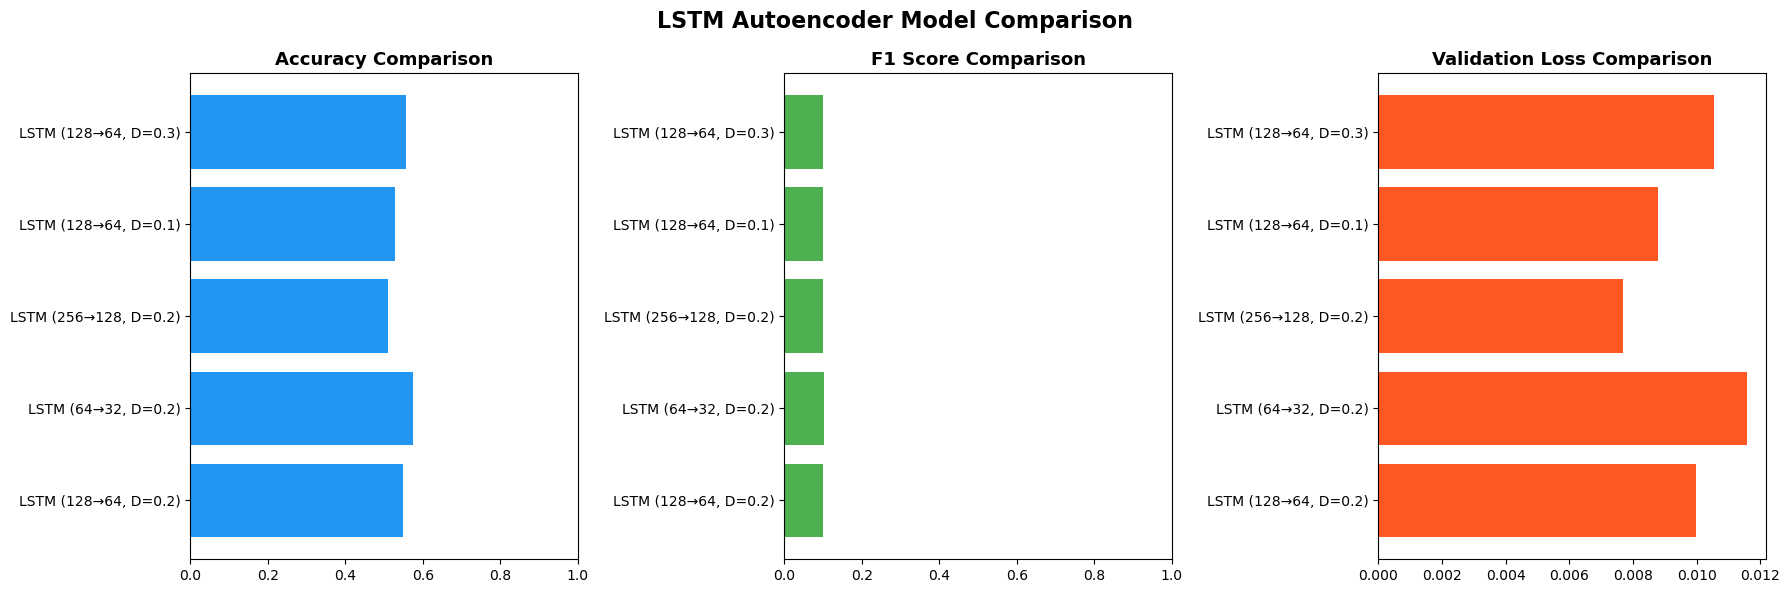

In [5]:
# Comparison Bar Chart
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
model_names = list(results.keys())
x = np.arange(len(model_names))

axes[0].barh(x, [results[n]['Accuracy'] for n in model_names], color='#2196F3')
axes[0].set_yticks(x); axes[0].set_yticklabels(model_names)
axes[0].set_title('Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0].set_xlim(0,1)

axes[1].barh(x, [results[n]['F1 Score'] for n in model_names], color='#4CAF50')
axes[1].set_yticks(x); axes[1].set_yticklabels(model_names)
axes[1].set_title('F1 Score Comparison', fontsize=13, fontweight='bold')
axes[1].set_xlim(0,1)

axes[2].barh(x, [results[n]['Val Loss'] for n in model_names], color='#FF5722')
axes[2].set_yticks(x); axes[2].set_yticklabels(model_names)
axes[2].set_title('Validation Loss Comparison', fontsize=13, fontweight='bold')

plt.suptitle('LSTM Autoencoder Model Comparison', fontsize=16, fontweight='bold')
plt.tight_layout(); plt.show()